In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

import joblib

In [11]:

df=pd.read_csv("india_housing_prices.csv")
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [18]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [12]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [15]:
df.duplicated(keep='first')

0         False
1         False
2         False
3         False
4         False
          ...  
249995    False
249996    False
249997    False
249998    False
249999    False
Length: 250000, dtype: bool

In [21]:
# Remove duplicates
df.drop_duplicates(inplace=True)


# Handle missing values (only if present)
if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)
    df.fillna(df.mode().iloc[0], inplace=True)

In [22]:
# Price per SqFt
df["Price_per_SqFt"] = (df["Price_in_Lakhs"] * 100000) / df["Size_in_SqFt"]

# Age of property
df["Age_of_Property"] = 2026 - df["Year_Built"]

# Amenities count
df["Amenities_Count"] = df["Amenities"].apply(lambda x: len(str(x).split(",")))

# School score
df["School_Score"] = df["Nearby_Schools"] / (df["Size_in_SqFt"] + 1)

In [24]:
df["Future_Price"] = df["Price_in_Lakhs"] * (1.08)**5

In [25]:
median_price = df["Price_per_SqFt"].median()

df["Good_Investment"] = (
    (df["Price_per_SqFt"] < median_price) &
    (df["Nearby_Schools"] > 2) &
    (df["Amenities_Count"] > 2)
).astype(int)

# EDA 

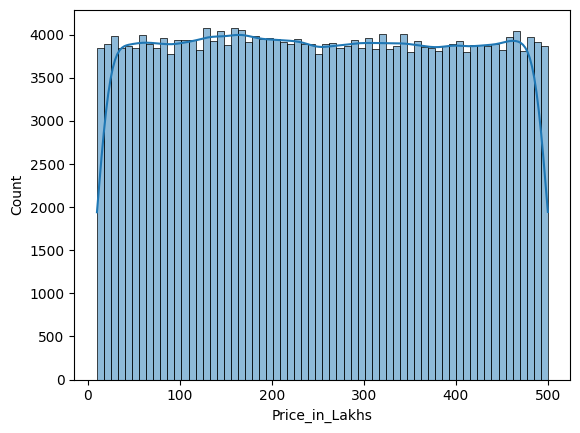

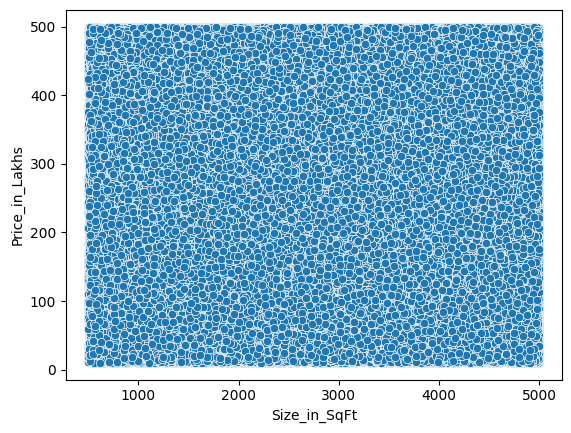

In [36]:
sns.histplot(df["Price_in_Lakhs"], kde=True)
plt.show()

sns.scatterplot(x=df["Size_in_SqFt"], y=df["Price_in_Lakhs"])
plt.show()

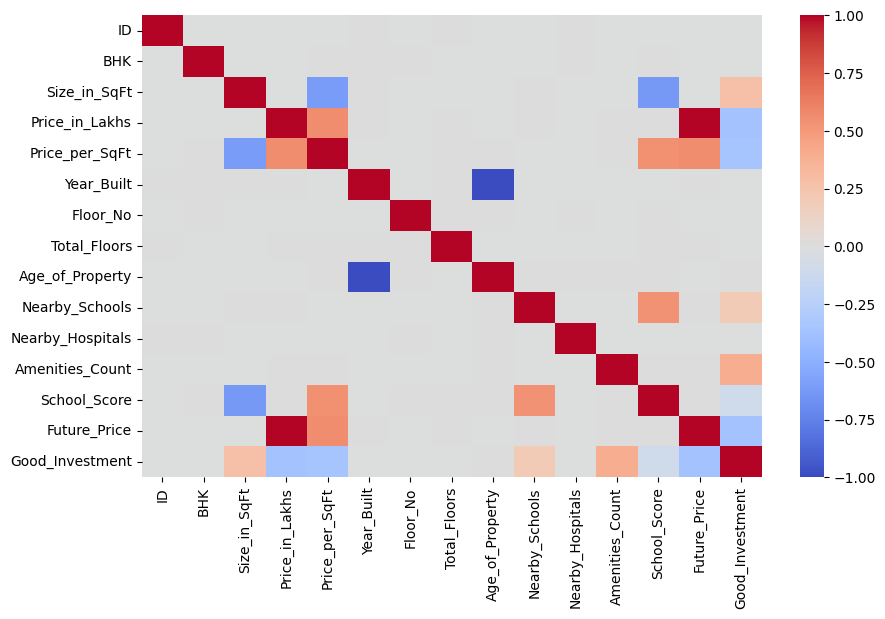

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [45]:
df = df.drop(["City", "State", "Owner_Type"], axis=1, errors='ignore')

In [46]:
cat_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [47]:
X = df.drop(["Future_Price", "Good_Investment", "ID"], axis=1)

y_reg = df["Future_Price"]
y_clf = df["Good_Investment"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
reg = RandomForestRegressor(
    n_estimators=30,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)

reg.fit(X_train, y_reg_train)

,n_estimators,30
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
clf = DecisionTreeClassifier(max_depth=10)
clf.fit(X_train, y_clf_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [58]:
y_pred_clf = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_clf_test, y_pred_clf))
print(classification_report(y_clf_test, y_pred_clf))

Accuracy: 0.99998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37960
           1       1.00      1.00      1.00     12040

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



In [59]:
y_pred_reg = reg.predict(X_test)

import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
print("RMSE:", rmse)

RMSE: 0.4537748812053561


In [62]:
import joblib

joblib.dump(reg, "reg_model.pkl")
joblib.dump(clf, "clf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# 🔥 Save feature columns
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [63]:
import joblib

joblib.dump(reg, "reg_model.pkl")
joblib.dump(clf, "clf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']